In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="2tWFKspMzTqGYsqsL4su")
project = rf.workspace("fire-detection-5id9d").project("fire-and-smoke-detection-0t7wg")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 131.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.5 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.1
    Uninstalling typer-0.27.1:
      Successfully uninstalled typer-0.27.1
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fire-And-Smoke-Detection-1 in yolov8:: 100%|██████████| 28606/28606 [00:07<00:00, 4062.99it/s]


In [2]:
!ls /content/


Fire-And-Smoke-Detection-1  sample_data


In [3]:
!ls -R /content/Fire-And-Smoke-Detection-1 | head -40

/content/Fire-And-Smoke-Detection-1:
data.yaml
README.dataset.txt
README.roboflow.txt
test
train
valid

/content/Fire-And-Smoke-Detection-1/test:
images
labels

/content/Fire-And-Smoke-Detection-1/test/images:
fire_0003_jpg.rf.003d1f4f73db8ee3c6a4775648353683.jpg
fire_0019_jpg.rf.fa1d37680dbee971f33a01e1ba94842a.jpg
fire_0047_jpg.rf.fccbc2a1b1fbe3bba9cd1b51407c6055.jpg
fire_0049_jpg.rf.70a5c662f05a5bc4590d1e66d840a0ed.jpg
fire_0053_jpg.rf.6c9a88745ec5562ad13dd99dbc56e79a.jpg
fire_0054_jpg.rf.276611cf8e23797706accbdd4df590cb.jpg
fire_0061_jpg.rf.98f1a3fb366d4ad77841afe246c59e90.jpg
fire_0064_jpg.rf.a2f76a4cbf3bb73b2cde76907a2e2a61.jpg
fire_0073_jpg.rf.5a2813edc73c2cd6c718aeaaa7deb397.jpg
fire_0076_jpg.rf.084205f6783df134e33d77b5076f1ffa.jpg
fire_0087_jpg.rf.a8ddf38c8de13f8eaf5e80eb33a283c6.jpg
fire_0091_jpg.rf.27c28c896967b3071aa571929d20441d.jpg
fire_0117_jpg.rf.bc0459b167256017ad7d9542f67b25db.jpg
fire_0119_jpg.rf.73a8c2b492be2292908b273e871b2e9b.jpg
fire_0121_jpg.rf.bb74d2c03f47970be

In [4]:
!ls /content/Fire-And-Smoke-Detection-1/train/labels/ | head -5

fire_0001_jpg.rf.2eae48f85759ffed0477a88c273a4352.txt
fire_0001_jpg.rf.dc0c906830dbfb998d22f13ec46baa0d.txt
fire_0001_jpg.rf.e4811b2f990682add05318d810bb7bd2.txt
fire_0002_jpg.rf.1fe93e4904c6cfba20b7eec0939a938e.txt
fire_0002_jpg.rf.d7670969305260a3716be6fb7934d192.txt


In [5]:
!cat /content/Fire-And-Smoke-Detection-1/train/labels/fire_0001_jpg.rf.2eae48f85759ffed0477a88c273a4352.txt

0 0.4203125 0.1296875 0.1875 0.259375
0 0.665625 0.1515625 0.2515625 0.2890625
0 0.165625 0.8546875 0.2296875 0.290625

In [6]:
!cat /content/Fire-And-Smoke-Detection-1/data.yml

cat: /content/Fire-And-Smoke-Detection-1/data.yml: No such file or directory


In [7]:
!cat /content/Fire-And-Smoke-Detection-1/data.yaml

names:
- fire
- smoke
nc: 2
roboflow:
  license: CC BY 4.0
  project: fire-and-smoke-detection-0t7wg
  url: https://universe.roboflow.com/fire-detection-5id9d/fire-and-smoke-detection-0t7wg/dataset/1
  version: 1
  workspace: fire-detection-5id9d
test: ../test/images
train: ../train/images
val: ../valid/images


In [8]:
import yaml

data_yaml_path = "/content/Fire-And-Smoke-Detection-1/data.yaml"

with open(data_yaml_path, "r") as f:
    data_config = yaml.safe_load(f)

data_config["train"] = "/content/Fire-And-Smoke-Detection-1/train/images"
data_config["val"]   = "/content/Fire-And-Smoke-Detection-1/valid/images"
data_config["test"]  = "/content/Fire-And-Smoke-Detection-1/test/images"

with open(data_yaml_path, "w") as f:
    yaml.dump(data_config, f)

!cat /content/Fire-And-Smoke-Detection-1/data.yaml

names:
- fire
- smoke
nc: 2
roboflow:
  license: CC BY 4.0
  project: fire-and-smoke-detection-0t7wg
  url: https://universe.roboflow.com/fire-detection-5id9d/fire-and-smoke-detection-0t7wg/dataset/1
  version: 1
  workspace: fire-detection-5id9d
test: /content/Fire-And-Smoke-Detection-1/test/images
train: /content/Fire-And-Smoke-Detection-1/train/images
val: /content/Fire-And-Smoke-Detection-1/valid/images


# Install Ultralytics + Load the model

In [9]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.4/65.4 kB 4.8 MB/s eta 0:00:00


In [10]:
from ultralytics import YOLO

# load a pretrained YOLOv8 model
model = YOLO("yolov8s.pt")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


yolov8s.pt = the small variant, pretrained on COCO (80 classes, millions of images)

# Training

In [11]:
results = model.train(
    data="/content/Fire-And-Smoke-Detection-1/data.yaml",
    epochs=20,
    imgsz=416,
    batch=16,
    patience=5,
    project="/content/runs",
    name="fire_smoke_v12"
)

Ultralytics 8.4.129 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Fire-And-Smoke-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=fire_smoke_v12, 

**data** -> we give their path to our data.yaml, that tell YOLO where images/labels are and also class names.

**epochs** -> number of passes over the entire training dataset. means model sees all 5.9k images 50 times.

**imgsz=640** -> all images resized to 640x640 before feeding into the network.

**batch=16** -> how many images processed together in one forward/backward pass before updating weights.

**patience=10** -> early stopping. if validation performance doesn't improve for 10 consecutive epochs, training stops automatically -- that save time.

**project/name** -> just controls where results get saved.

**GPU_mem** -> GPU memory used for this batch. if it creeps toward your GPU's max, that's when you'd lower `batch`.

**Instances** -> number of ground-truth boxes present in this specific batch. not a loss, just a count.

**Size** -> input image size (640, matching imgsz) plus % progress through the current epoch.

**box_loss** -> how wrong the predicted bounding box coordinates are vs ground truth. uses CIoU loss (overlap + aspect ratio + center distance). lower = boxes positioned/sized more accurately.

**cls_loss** -> classification loss, is the model correctly saying fire vs smoke. uses binary cross-entropy. lower = more confident and correct about which class.

**dfl_loss** -> Distribution Focal Loss. refines box edge precision by predicting a distribution instead of one number. helps with fuzzy-edged objects like smoke.

**Total loss** -> what the optimizer actually minimizes = λ_box · box_loss + λ_cls · cls_loss + λ_dfl · dfl_loss. all three should trend downward epoch over epoch.

# Read the full results properly.

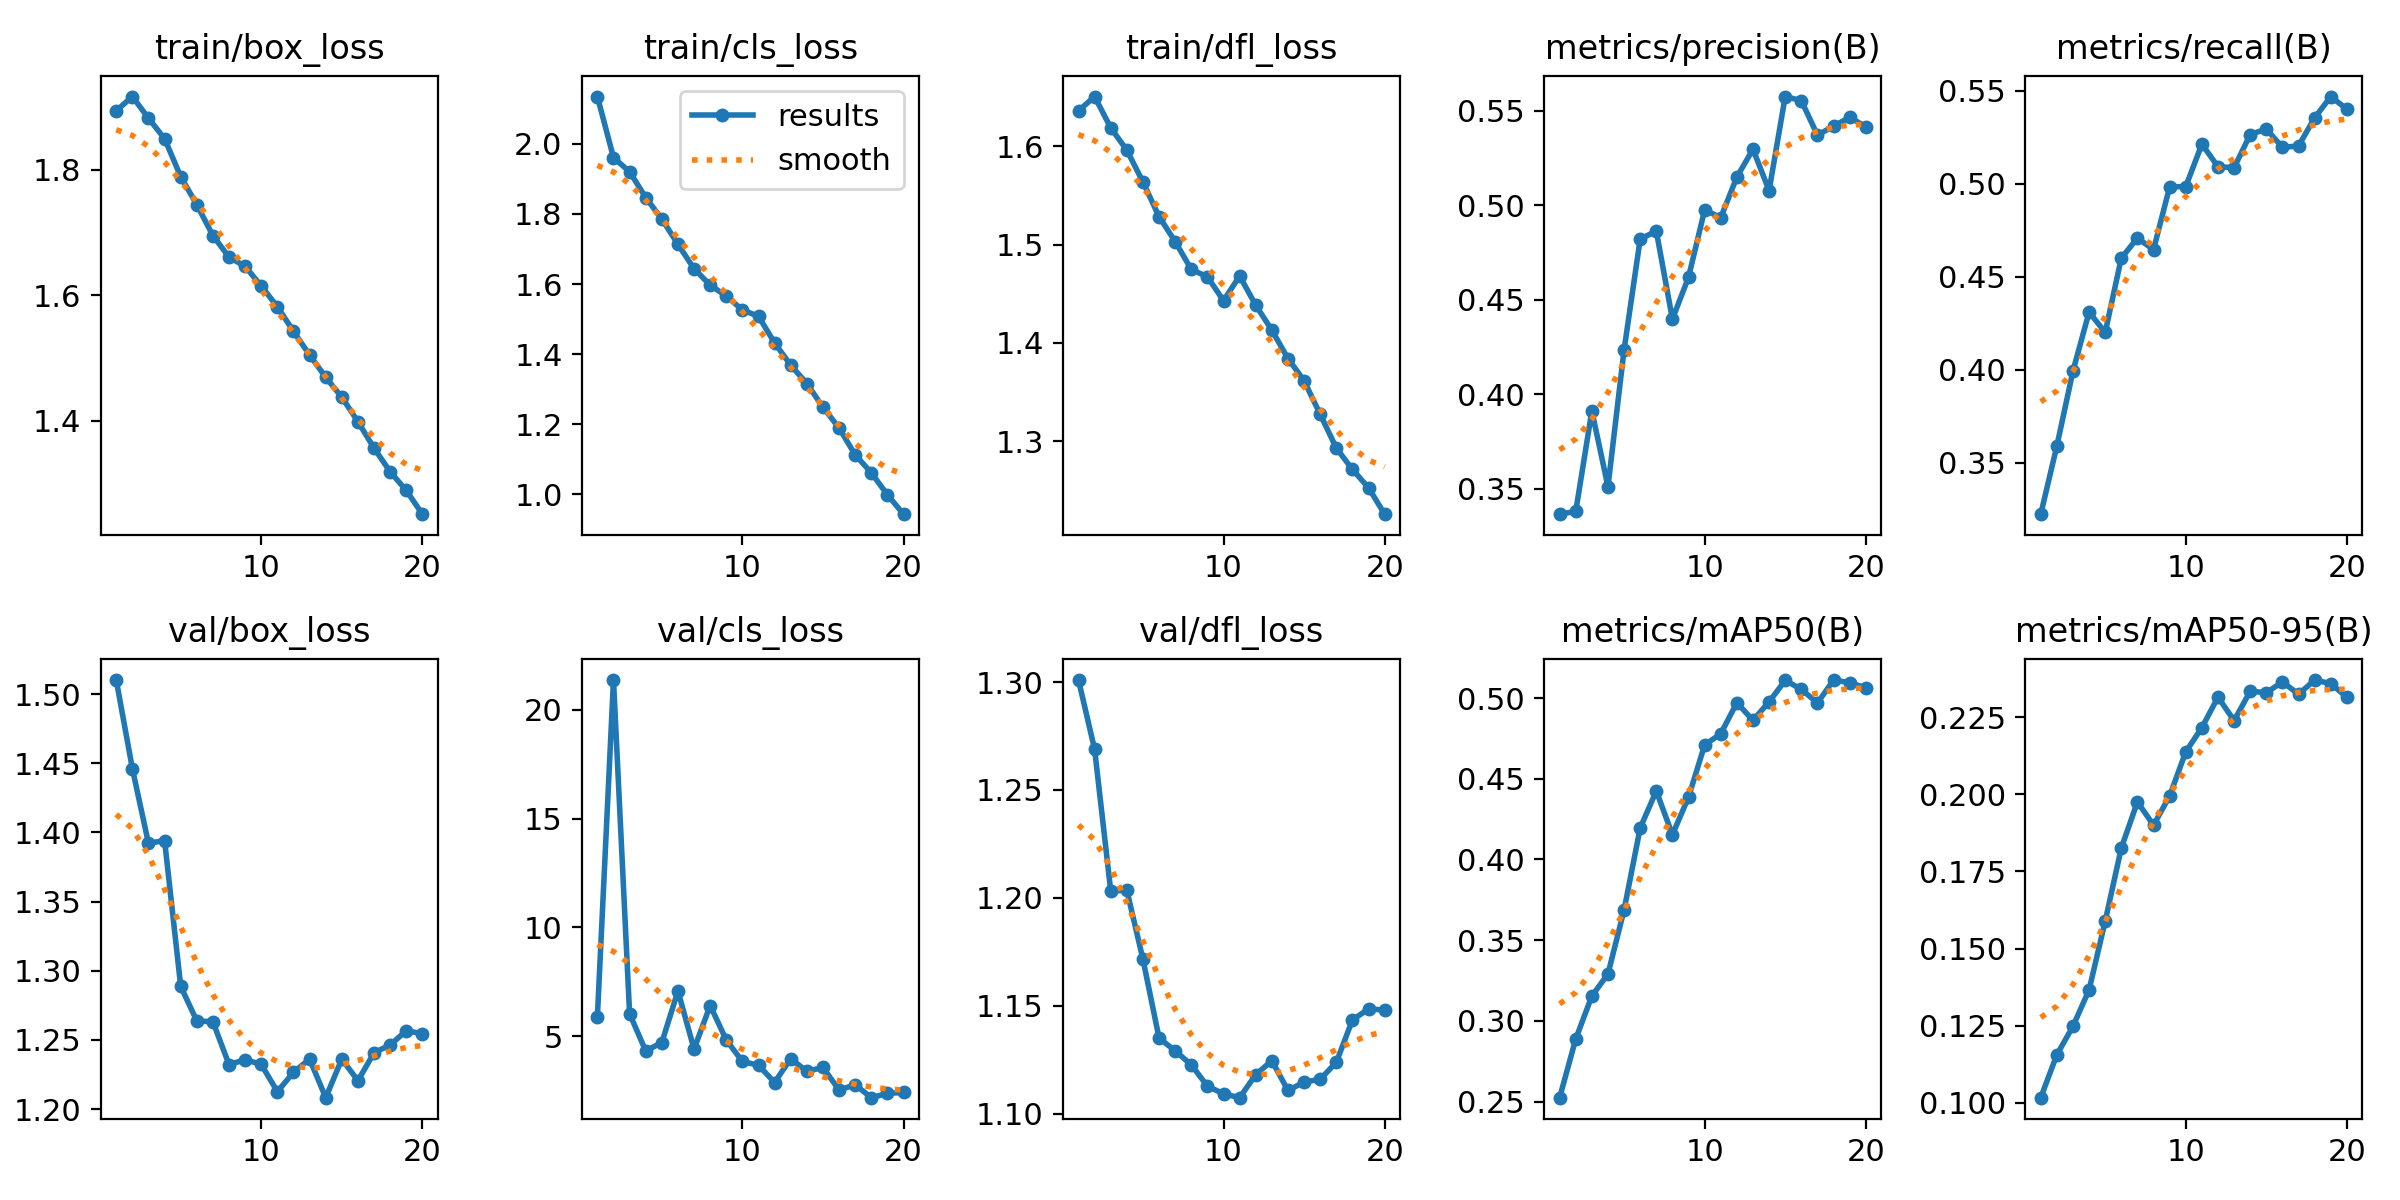

In [12]:
from IPython.display import Image, display

# loss + mAP curves across all 20 epochs
display(Image(filename="/content/runs/fire_smoke_v12/results.png", width=900))

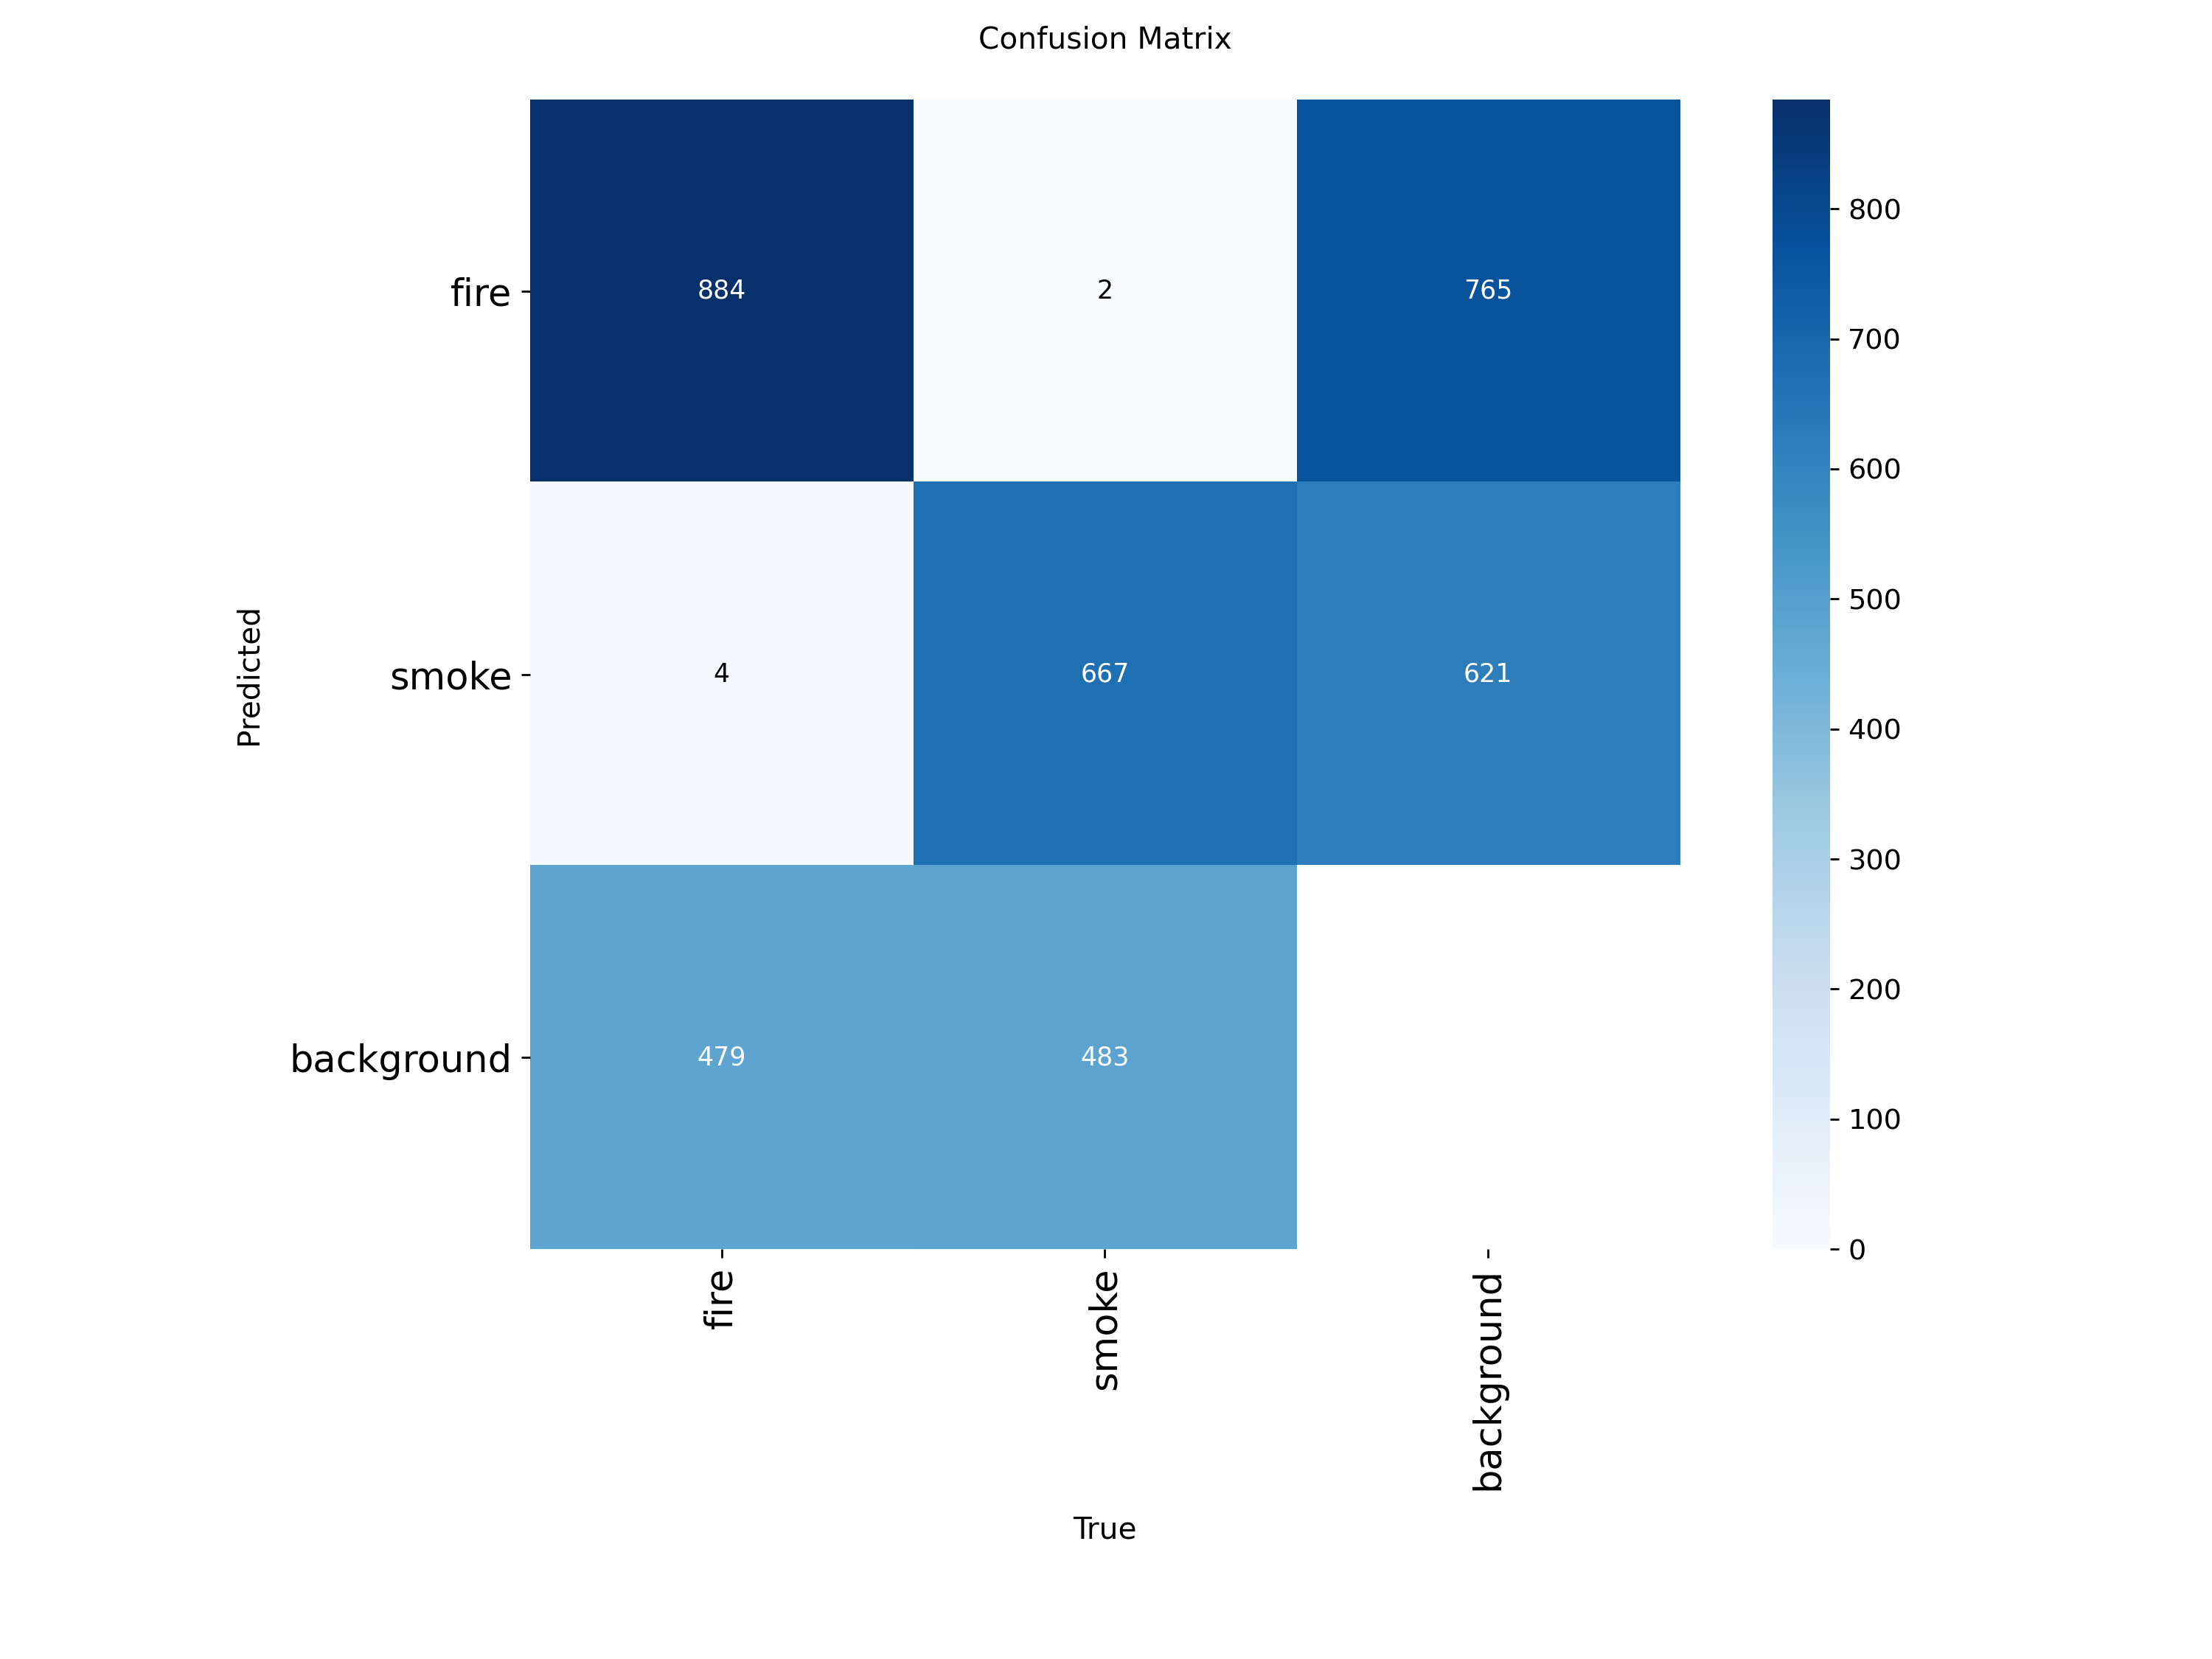

In [13]:
# confusion matrix — where model confuses fire vs smoke vs background
display(Image(filename="/content/runs/fire_smoke_v12/confusion_matrix.png", width=700))

# Adjusting paths to your actual run folder (fire_smoke_v12):

In [14]:
from ultralytics import YOLO

# load the best trained checkpoint
best_model = YOLO("/content/runs/fire_smoke_v12/weights/best.pt")

In [15]:
# run inference on test-set images
results = best_model.predict(
    source="/content/Fire-And-Smoke-Detection-1/test/images",
    conf=0.4,        # only show predictions with >=40% confidence
    save=True         # saves annotated images to /content/runs/detect/predict
)


image 1/596 /content/Fire-And-Smoke-Detection-1/test/images/fire_0003_jpg.rf.003d1f4f73db8ee3c6a4775648353683.jpg: 416x416 (no detections), 13.4ms
image 2/596 /content/Fire-And-Smoke-Detection-1/test/images/fire_0019_jpg.rf.fa1d37680dbee971f33a01e1ba94842a.jpg: 416x416 1 fire, 16.2ms
image 3/596 /content/Fire-And-Smoke-Detection-1/test/images/fire_0047_jpg.rf.fccbc2a1b1fbe3bba9cd1b51407c6055.jpg: 416x416 2 fires, 17.0ms
image 4/596 /content/Fire-And-Smoke-Detection-1/test/images/fire_0049_jpg.rf.70a5c662f05a5bc4590d1e66d840a0ed.jpg: 416x416 4 fires, 15.4ms
image 5/596 /content/Fire-And-Smoke-Detection-1/test/images/fire_0053_jpg.rf.6c9a88745ec5562ad13dd99dbc56e79a.jpg: 416x416 3 fires, 16.7ms
image 6/596 /content/Fire-And-Smoke-Detection-1/test/images/fire_0054_jpg.rf.276611cf8e23797706accbdd4df590cb.jpg: 416x416 5 fires, 14.2ms
image 7/596 /content/Fire-And-Smoke-Detection-1/test/images/fire_0061_jpg.rf.98f1a3fb366d4ad77841afe246c59e90.jpg: 416x416 4 fires, 12.5ms
image 8/596 /conten

Total predicted images: 596


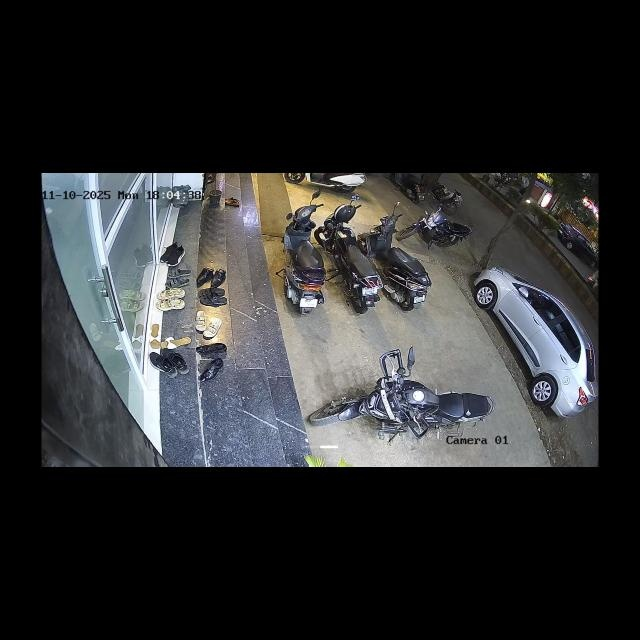

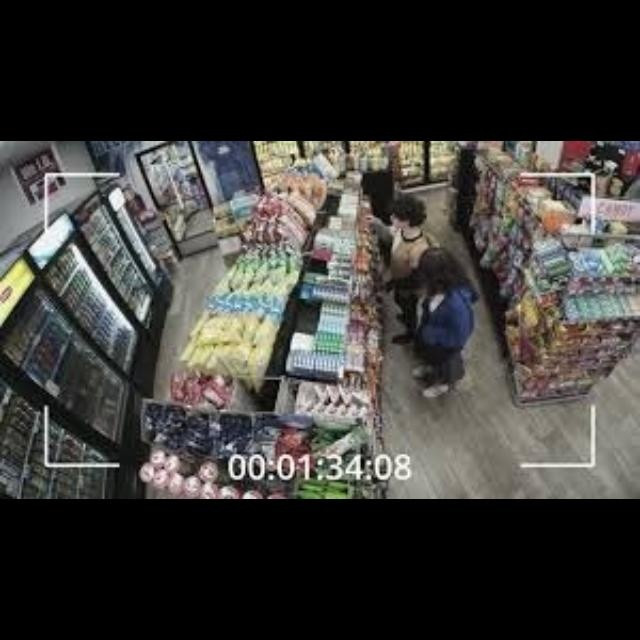

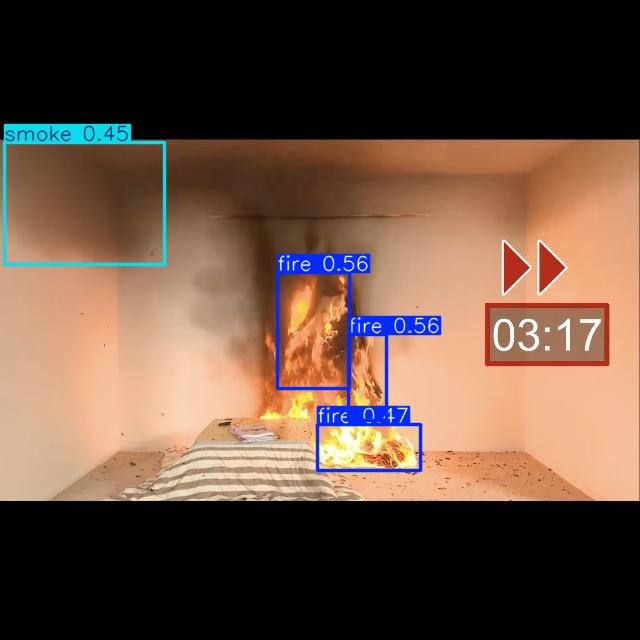

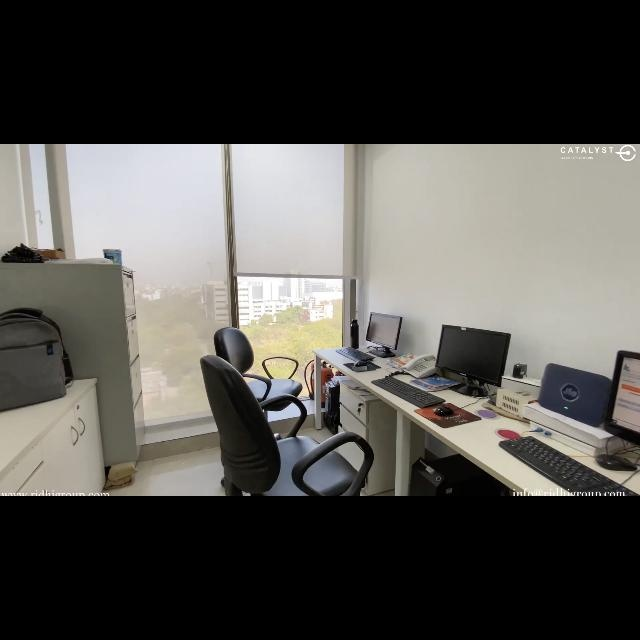

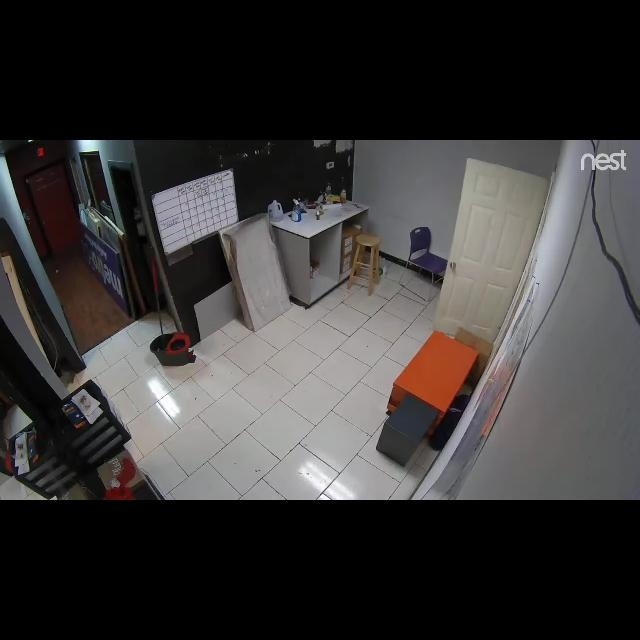

In [16]:
# display predicted images inline
from IPython.display import Image, display
import glob

pred_imgs = glob.glob("/content/runs/detect/predict/*.jpg")
print(f"Total predicted images: {len(pred_imgs)}")

for img_path in pred_imgs[:5]:   # show first 5
    display(Image(filename=img_path, width=700))